# 02 - Exploratory Data Analysis & Customer Insights
## Customer Feedback Intelligence System

### Objectives:
- Derive explicit `Sentiment` classes from customer ratings (Supervised Target).
- Analyze rating and recommendation distributions.
- Investigate feedback patterns across departments and garment classes.
- Export high-resolution analytical figures for reports and presentation.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

DATA_PATH = Path("../data/processed/cleaned_reviews.csv")
FIGURES_PATH = Path("../reports/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [2]:
# 1. Feature Engineering: Define Sentiment Labels
# Rating 1-2 -> Negative, Rating 3 -> Neutral, Rating 4-5 -> Positive
def map_sentiment(rating: int) -> str:
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    return "Positive"

df["Sentiment"] = df["Rating"].apply(map_sentiment)
df["Review Length"] = df["Review Text"].str.len()
df["Word Count"] = df["Review Text"].str.split().str.len()

print("Sentiment Class Counts:")
print(df["Sentiment"].value_counts())
print("\nSentiment Class Proportions (%):")
print((df["Sentiment"].value_counts(normalize=True) * 100).round(2))

Sentiment Class Counts:
Sentiment
Positive    17434
Neutral      2823
Negative     2369
Name: count, dtype: int64

Sentiment Class Proportions (%):
Sentiment
Positive    77.05
Neutral     12.48
Negative    10.47
Name: proportion, dtype: float64


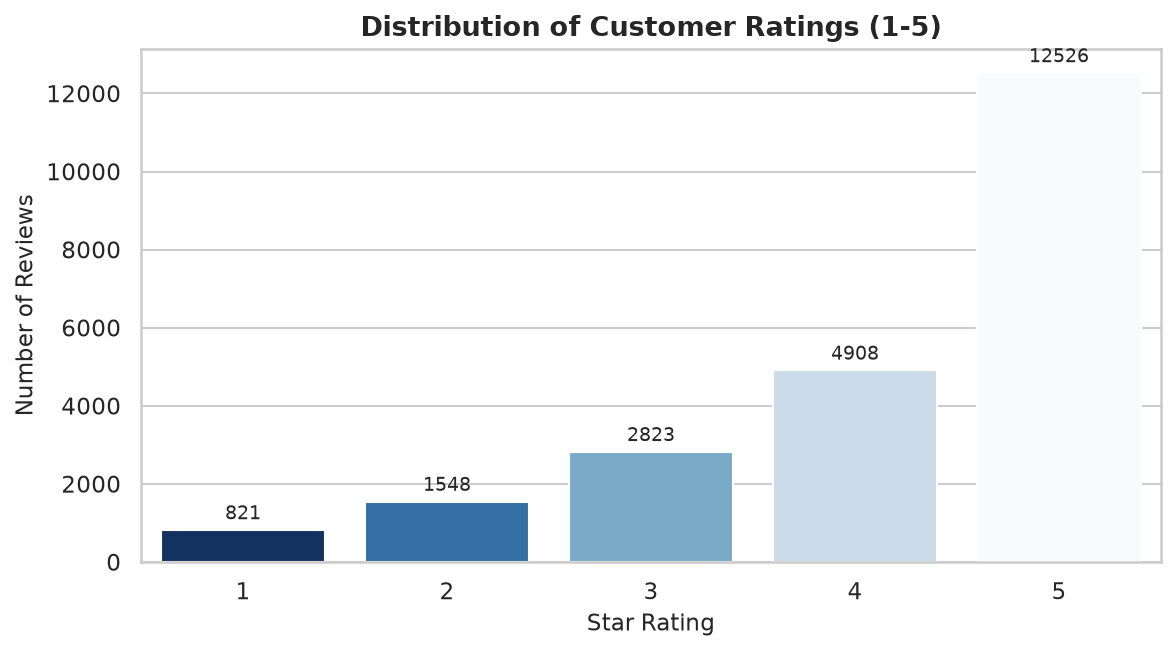

In [3]:
# 2. Rating Distribution Plot
plt.figure(figsize=(8, 4.5))
ax = sns.countplot(data=df, x="Rating", hue="Rating", palette="Blues_r", legend=False)
plt.title("Distribution of Customer Ratings (1-5)", fontsize=13, fontweight="bold")
plt.xlabel("Star Rating", fontsize=11)
plt.ylabel("Number of Reviews", fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES_PATH / "rating_distribution.png")
plt.show()

C:\Users\Royal\AppData\Local\Temp\ipykernel_30948\4133026141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Sentiment", order=["Negative", "Neutral", "Positive"], palette=sentiment_palette, legend=False)


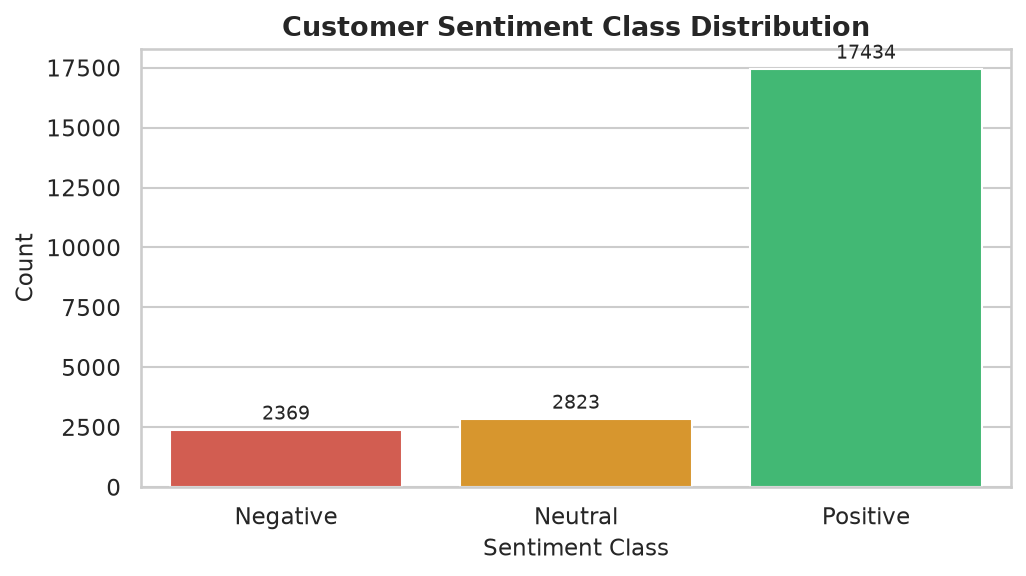

In [4]:
# 3. Sentiment Distribution Plot
plt.figure(figsize=(7, 4))
sentiment_palette = {"Negative": "#e74c3c", "Neutral": "#f39c12", "Positive": "#2ecc71"}
ax = sns.countplot(data=df, x="Sentiment", order=["Negative", "Neutral", "Positive"], palette=sentiment_palette, legend=False)
plt.title("Customer Sentiment Class Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Sentiment Class", fontsize=11)
plt.ylabel("Count", fontsize=11)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
plt.savefig(FIGURES_PATH / "sentiment_distribution.png")
plt.show()

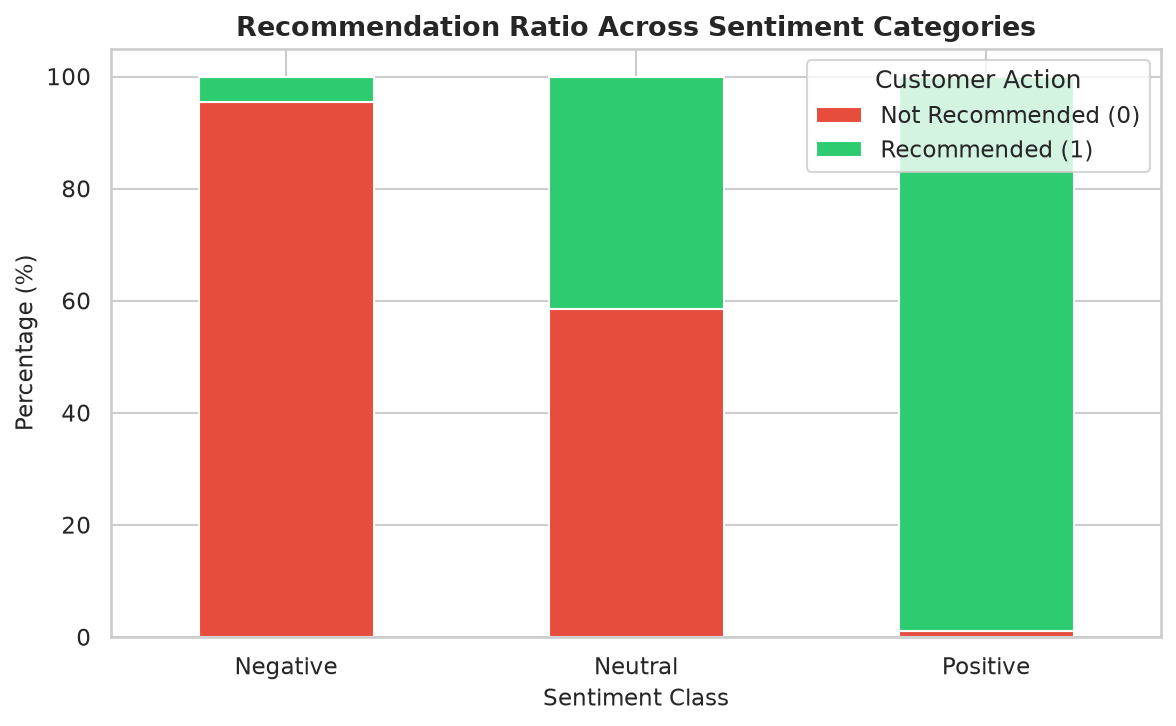

In [5]:
# 4. Sentiment vs. Recommendation Indicator
rec_ct = pd.crosstab(df["Sentiment"], df["Recommended IND"], normalize="index") * 100

rec_ct.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#e74c3c", "#2ecc71"])
plt.title("Recommendation Ratio Across Sentiment Categories", fontsize=13, fontweight="bold")
plt.xlabel("Sentiment Class", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)
plt.xticks(rotation=0)
plt.legend(["Not Recommended (0)", "Recommended (1)"], title="Customer Action")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "sentiment_vs_recommendation.png")
plt.show()

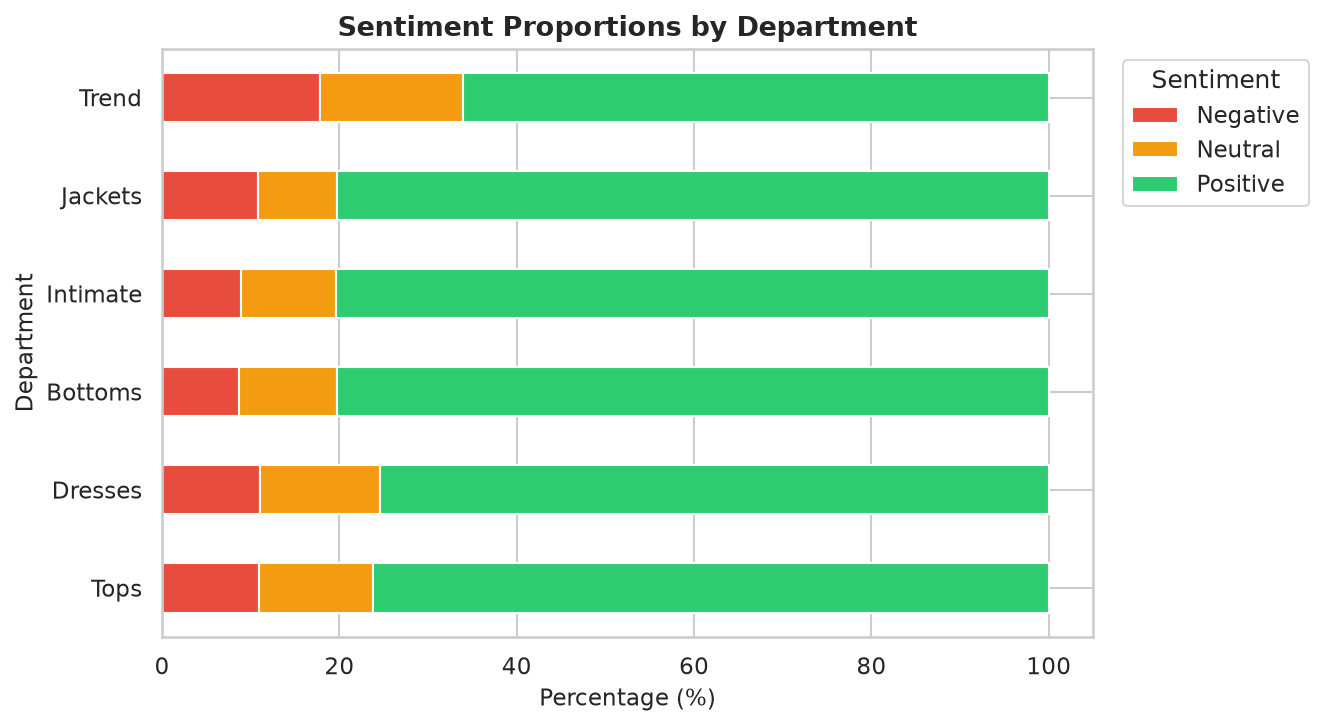

In [6]:
# 5. Department Volume and Sentiment Breakdown
dept_order = df["Department Name"].value_counts().index
dept_sentiment = pd.crosstab(df["Department Name"], df["Sentiment"], normalize="index")[["Negative", "Neutral", "Positive"]] * 100

dept_sentiment.loc[dept_order].plot(kind="barh", stacked=True, figsize=(9, 5), color=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Sentiment Proportions by Department", fontsize=13, fontweight="bold")
plt.xlabel("Percentage (%)", fontsize=11)
plt.ylabel("Department", fontsize=11)
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_PATH / "department_sentiment_breakdown.png")
plt.show()